# 使用Torch.nn实现前馈神经网络解决回归、二分类、多分类任务

In [1]:
# 导入所需的库

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
import time
import warnings
warnings.filterwarnings('ignore')

In [2]:
# 设置随机种子
torch.manual_seed(2025)
np.random.seed(2025)

## 定义神经网络

In [3]:
# 定义神经网络模型
class FeedForwardNN(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size, activation='relu', dropout_rate=0.0):
        super(FeedForwardNN, self).__init__()
        
        # 构建网络层
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            
            if activation == 'relu':
                layers.append(nn.ReLU())
            elif activation == 'sigmoid':
                layers.append(nn.Sigmoid())
            elif activation == 'tanh':
                layers.append(nn.Tanh())
            elif activation == 'leaky_relu':
                layers.append(nn.LeakyReLU())
            
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            
            prev_size = hidden_size
        
        # 输出层
        layers.append(nn.Linear(prev_size, output_size))
        
        self.network = nn.Sequential(*layers)
        
        # 初始化权重
        self._initialize_weights()
    
    def _initialize_weights(self):
        for layer in self.network:
            if isinstance(layer, nn.Linear):
                nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
                nn.init.zeros_(layer.bias)
    
    def forward(self, x):
        return self.network(x)

# 训练函数
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs, task_type, device):
    model.to(device)
    train_losses = []
    val_losses = []
    val_accuracies = []
    
    start_time = time.time()
    
    for epoch in range(epochs):
        # 训练阶段
        model.train()
        train_loss = 0.0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            
            if task_type == 'multiclass_classification':
                loss = criterion(outputs, batch_y.long())
            else:
                loss = criterion(outputs, batch_y)
            
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        # 验证阶段
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                
                if task_type == 'multiclass_classification':
                    val_loss += criterion(outputs, batch_y.long()).item()
                    _, predicted = torch.max(outputs.data, 1)
                    correct += (predicted == batch_y).sum().item()
                else:
                    val_loss += criterion(outputs, batch_y).item()
                    if task_type == 'binary_classification':
                        predicted = (outputs > 0.5).float()
                        correct += (predicted == batch_y).sum().item()
                    else:
                        # 回归任务不计算准确率
                        pass
                
                total += batch_y.size(0)
        
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        
        if task_type != 'regression':
            val_accuracy = correct / total
            val_accuracies.append(val_accuracy)
        else:
            val_accuracies.append(0)  # 回归任务不计算准确率
        
        if epoch % 50 == 0:
            if task_type != 'regression':
                print(f'Epoch [{epoch}/{epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}')
            else:
                print(f'Epoch [{epoch}/{epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')
    
    training_time = time.time() - start_time
    print(f'Training completed in {training_time:.2f} seconds')
    
    return train_losses, val_losses, val_accuracies, training_time

# 评估函数
def evaluate_model(model, test_loader, task_type, device):
    model.eval()
    model.to(device)
    
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            
            if task_type == 'binary_classification':
                predictions = (outputs > 0.5).float()
            elif task_type == 'multiclass_classification':
                _, predictions = torch.max(outputs, 1)
            else:
                predictions = outputs
            
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(batch_y.cpu().numpy())
    
    all_predictions = np.concatenate(all_predictions)
    all_targets = np.concatenate(all_targets)
    
    if task_type == 'regression':
        mse = np.mean((all_targets - all_predictions) ** 2)
        rmse = np.sqrt(mse)
        mae = np.mean(np.abs(all_targets - all_predictions))
        return {'mse': mse, 'rmse': rmse, 'mae': mae}
    
    elif task_type == 'binary_classification':
        accuracy = np.mean(all_targets == all_predictions)
        from sklearn.metrics import precision_score, recall_score, f1_score
        precision = precision_score(all_targets, all_predictions)
        recall = recall_score(all_targets, all_predictions)
        f1 = f1_score(all_targets, all_predictions)
        return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}
    
    elif task_type == 'multiclass_classification':
        accuracy = np.mean(all_targets == all_predictions)
        from sklearn.metrics import classification_report
        return {'accuracy': accuracy}

## 数据集生成

In [4]:

# 1. 生成回归数据集
print("生成回归数据集...")
p = 500
n_samples = 10000

X_reg = np.random.randn(n_samples, p).astype(np.float32)
epsilon = np.random.randn(n_samples, 1).astype(np.float32) * 0.1
y_reg = 0.028 + 0.0056 * np.sum(X_reg, axis=1, keepdims=True) + epsilon

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)

# 进一步分割训练集为训练和验证
X_reg_train, X_reg_val, y_reg_train, y_reg_val = train_test_split(
    X_reg_train, y_reg_train, test_size=0.2, random_state=42
)


生成回归数据集...


In [5]:

# 2. 生成二分类数据集
print("生成二分类数据集...")
n_features = 200

# 第一个类别
X1 = np.random.randn(5000, n_features).astype(np.float32) + 1.0
y1 = np.zeros((5000, 1), dtype=np.float32)

# 第二个类别
X2 = np.random.randn(5000, n_features).astype(np.float32) - 1.0
y2 = np.ones((5000, 1), dtype=np.float32)

X_binary = np.vstack([X1, X2])
y_binary = np.vstack([y1, y2])

# 打乱数据
indices = np.random.permutation(len(X_binary))
X_binary = X_binary[indices]
y_binary = y_binary[indices]

X_binary_train, X_binary_test, y_binary_train, y_binary_test = train_test_split(
    X_binary, y_binary, test_size=0.3, random_state=42
)

X_binary_train, X_binary_val, y_binary_train, y_binary_val = train_test_split(
    X_binary_train, y_binary_train, test_size=0.2, random_state=42
)


生成二分类数据集...


In [6]:

# 3. 加载MNIST数据集
print("加载MNIST数据集...")
train_dataset_mnist = torchvision.datasets.MNIST(root='./Datasets/MNIST', train=True, download=True, transform=torchvision.transforms.ToTensor())
test_dataset_mnist = torchvision.datasets.MNIST(root='./Datasets/MNIST', train=False, download=True, transform=torchvision.transforms.ToTensor())
train_loader = torch.utils.data.DataLoader(dataset=train_dataset_mnist, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset_mnist, batch_size=32, shuffle=False)

X_mnist = np.vstack([train_dataset_mnist.data.numpy().reshape(-1, 784), test_dataset_mnist.data.numpy().reshape(-1, 784)]).astype(np.float32)
y_mnist = np.hstack([train_dataset_mnist.targets.numpy(), test_dataset_mnist.targets.numpy()]).astype(int)
    
# 标准化
scaler = StandardScaler()
X_mnist = scaler.fit_transform(X_mnist)

# 分割数据集
X_mnist_train, X_mnist_test, y_mnist_train, y_mnist_test = train_test_split(
    X_mnist, y_mnist, test_size=0.3, random_state=42
)

X_mnist_train, X_mnist_val, y_mnist_train, y_mnist_val = train_test_split(
    X_mnist_train, y_mnist_train, test_size=0.2, random_state=42
)


加载MNIST数据集...


In [7]:

# 设置设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

# 训练和评估结果存储
results = {}



使用设备: cpu


## 训练

In [8]:
# 回归任务
print("\n" + "="*50)
print("回归任务训练")
print("="*50)

# 创建数据加载器
reg_train_dataset = TensorDataset(torch.FloatTensor(X_reg_train), torch.FloatTensor(y_reg_train))
reg_val_dataset = TensorDataset(torch.FloatTensor(X_reg_val), torch.FloatTensor(y_reg_val))
reg_test_dataset = TensorDataset(torch.FloatTensor(X_reg_test), torch.FloatTensor(y_reg_test))

reg_train_loader = DataLoader(reg_train_dataset, batch_size=64, shuffle=True)
reg_val_loader = DataLoader(reg_val_dataset, batch_size=64, shuffle=False)
reg_test_loader = DataLoader(reg_test_dataset, batch_size=64, shuffle=False)

# 创建模型
reg_model = FeedForwardNN(input_size=500, hidden_sizes=[256, 128, 64], output_size=1, activation='relu')
reg_criterion = nn.MSELoss()
reg_optimizer = optim.Adam(reg_model.parameters(), lr=0.001)

# 训练模型
reg_train_losses, reg_val_losses, _, reg_time = train_model(
    reg_model, reg_train_loader, reg_val_loader, reg_criterion, reg_optimizer, 
    epochs=300, task_type='regression', device=device
)

# 评估模型
reg_metrics = evaluate_model(reg_model, reg_test_loader, 'regression', device)

results['regression'] = {
    'train_losses': reg_train_losses,
    'val_losses': reg_val_losses,
    'training_time': reg_time,
    'metrics': reg_metrics
}




回归任务训练
Epoch [0/300], Train Loss: 0.2217, Val Loss: 0.0590
Epoch [50/300], Train Loss: 0.0008, Val Loss: 0.0211
Epoch [100/300], Train Loss: 0.0004, Val Loss: 0.0142
Epoch [150/300], Train Loss: 0.0004, Val Loss: 0.0125
Epoch [200/300], Train Loss: 0.0002, Val Loss: 0.0121
Epoch [250/300], Train Loss: 0.0001, Val Loss: 0.0118
Training completed in 97.43 seconds


In [9]:
# 二分类任务
print("\n" + "="*50)
print("二分类任务训练")
print("="*50)

# 创建数据加载器
binary_train_dataset = TensorDataset(torch.FloatTensor(X_binary_train), torch.FloatTensor(y_binary_train))
binary_val_dataset = TensorDataset(torch.FloatTensor(X_binary_val), torch.FloatTensor(y_binary_val))
binary_test_dataset = TensorDataset(torch.FloatTensor(X_binary_test), torch.FloatTensor(y_binary_test))

binary_train_loader = DataLoader(binary_train_dataset, batch_size=64, shuffle=True)
binary_val_loader = DataLoader(binary_val_dataset, batch_size=64, shuffle=False)
binary_test_loader = DataLoader(binary_test_dataset, batch_size=64, shuffle=False)

# 创建模型
binary_model = FeedForwardNN(input_size=200, hidden_sizes=[128, 64], output_size=1, activation='relu')
binary_criterion = nn.BCEWithLogitsLoss()
binary_optimizer = optim.Adam(binary_model.parameters(), lr=0.001)

# 训练模型
binary_train_losses, binary_val_losses, binary_val_acc, binary_time = train_model(
    binary_model, binary_train_loader, binary_val_loader, binary_criterion, binary_optimizer, 
    epochs=200, task_type='binary_classification', device=device
)

# 评估模型
binary_metrics = evaluate_model(binary_model, binary_test_loader, 'binary_classification', device)

results['binary_classification'] = {
    'train_losses': binary_train_losses,
    'val_losses': binary_val_losses,
    'val_accuracies': binary_val_acc,
    'training_time': binary_time,
    'metrics': binary_metrics
}



二分类任务训练
Epoch [0/200], Train Loss: 0.0335, Val Loss: 0.0000, Val Acc: 1.0000
Epoch [50/200], Train Loss: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000
Epoch [100/200], Train Loss: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000
Epoch [150/200], Train Loss: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000
Training completed in 48.41 seconds


In [10]:

# 多分类任务
print("\n" + "="*50)
print("多分类任务训练")
print("="*50)

# 创建数据加载器
mnist_train_dataset = TensorDataset(torch.FloatTensor(X_mnist_train), torch.LongTensor(y_mnist_train))
mnist_val_dataset = TensorDataset(torch.FloatTensor(X_mnist_val), torch.LongTensor(y_mnist_val))
mnist_test_dataset = TensorDataset(torch.FloatTensor(X_mnist_test), torch.LongTensor(y_mnist_test))

mnist_train_loader = DataLoader(mnist_train_dataset, batch_size=128, shuffle=True)
mnist_val_loader = DataLoader(mnist_val_dataset, batch_size=128, shuffle=False)
mnist_test_loader = DataLoader(mnist_test_dataset, batch_size=128, shuffle=False)

# 创建模型
mnist_model = FeedForwardNN(input_size=784, hidden_sizes=[512, 256, 128], output_size=10, activation='relu', dropout_rate=0.2)
mnist_criterion = nn.CrossEntropyLoss()
mnist_optimizer = optim.Adam(mnist_model.parameters(), lr=0.001, weight_decay=1e-5)

# 训练模型
mnist_train_losses, mnist_val_losses, mnist_val_acc, mnist_time = train_model(
    mnist_model, mnist_train_loader, mnist_val_loader, mnist_criterion, mnist_optimizer, 
    epochs=100, task_type='multiclass_classification', device=device
)

# 评估模型
mnist_metrics = evaluate_model(mnist_model, mnist_test_loader, 'multiclass_classification', device)




多分类任务训练
Epoch [0/100], Train Loss: 0.4427, Val Loss: 0.1806, Val Acc: 0.9473
Epoch [50/100], Train Loss: 0.0180, Val Loss: 0.1726, Val Acc: 0.9767
Training completed in 422.79 seconds


## 结果可视化

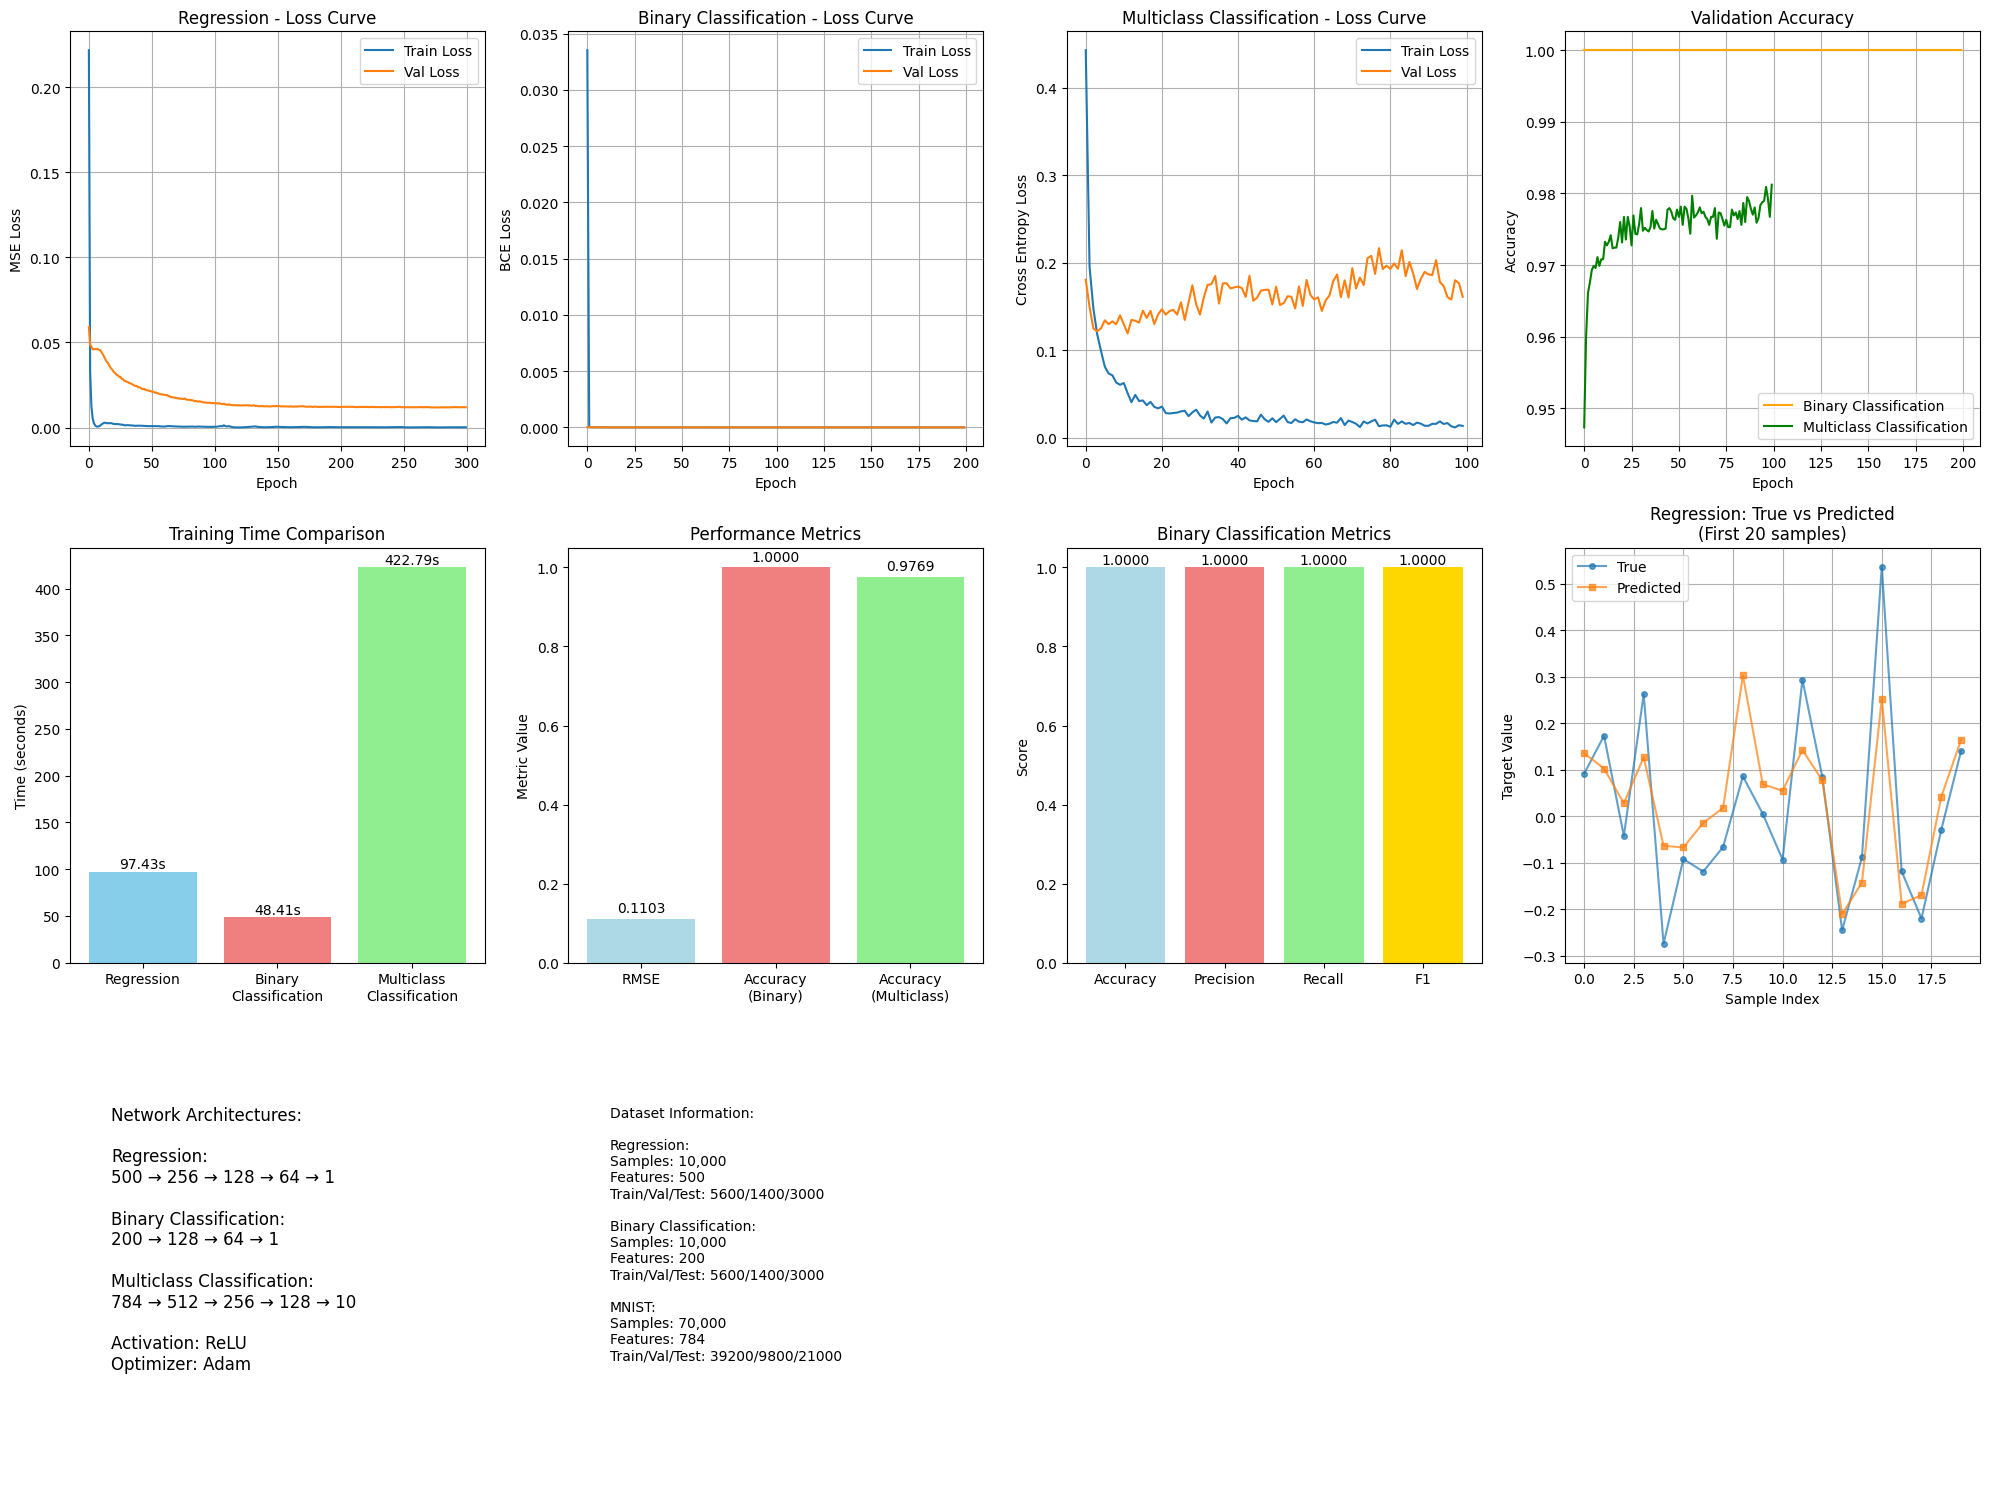

In [11]:
results['multiclass_classification'] = {
    'train_losses': mnist_train_losses,
    'val_losses': mnist_val_losses,
    'val_accuracies': mnist_val_acc,
    'training_time': mnist_time,
    'metrics': mnist_metrics
}

# 结果可视化
plt.figure(figsize=(20, 15))

# 1. 损失曲线
plt.subplot(3, 4, 1)
plt.plot(results['regression']['train_losses'], label='Train Loss')
plt.plot(results['regression']['val_losses'], label='Val Loss')
plt.title('Regression - Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)

plt.subplot(3, 4, 2)
plt.plot(results['binary_classification']['train_losses'], label='Train Loss')
plt.plot(results['binary_classification']['val_losses'], label='Val Loss')
plt.title('Binary Classification - Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.legend()
plt.grid(True)

plt.subplot(3, 4, 3)
plt.plot(results['multiclass_classification']['train_losses'], label='Train Loss')
plt.plot(results['multiclass_classification']['val_losses'], label='Val Loss')
plt.title('Multiclass Classification - Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Cross Entropy Loss')
plt.legend()
plt.grid(True)

# 2. 准确率曲线（分类任务）
plt.subplot(3, 4, 4)
plt.plot(results['binary_classification']['val_accuracies'], label='Binary Classification', color='orange')
plt.plot(results['multiclass_classification']['val_accuracies'], label='Multiclass Classification', color='green')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# 3. 训练时间比较
plt.subplot(3, 4, 5)
tasks = ['Regression', 'Binary\nClassification', 'Multiclass\nClassification']
times = [results['regression']['training_time'], 
         results['binary_classification']['training_time'],
         results['multiclass_classification']['training_time']]
bars = plt.bar(tasks, times, color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Training Time Comparison')
plt.ylabel('Time (seconds)')
for bar, time_val in zip(bars, times):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{time_val:.2f}s', ha='center', va='bottom')

# 4. 性能指标比较
plt.subplot(3, 4, 6)
metrics_names = ['RMSE', 'Accuracy\n(Binary)', 'Accuracy\n(Multiclass)']
metrics_values = [
    results['regression']['metrics']['rmse'],
    results['binary_classification']['metrics']['accuracy'],
    results['multiclass_classification']['metrics']['accuracy']
]
bars = plt.bar(metrics_names, metrics_values, color=['lightblue', 'lightcoral', 'lightgreen'])
plt.title('Performance Metrics')
plt.ylabel('Metric Value')
for bar, value in zip(bars, metrics_values):
    if bar.get_height() < 0.1:  # RMSE
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
                 f'{value:.4f}', ha='center', va='bottom')
    else:  # Accuracy
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                 f'{value:.4f}', ha='center', va='bottom')

# 5. 二分类任务详细指标
plt.subplot(3, 4, 7)
binary_metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1']
binary_metrics_values = [
    results['binary_classification']['metrics']['accuracy'],
    results['binary_classification']['metrics']['precision'],
    results['binary_classification']['metrics']['recall'],
    results['binary_classification']['metrics']['f1']
]
plt.bar(binary_metrics_names, binary_metrics_values, color=['lightblue', 'lightcoral', 'lightgreen', 'gold'])
plt.title('Binary Classification Metrics')
plt.ylabel('Score')
for i, v in enumerate(binary_metrics_values):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center')

# 6. 回归任务预测示例
plt.subplot(3, 4, 8)
# 选择前20个测试样本进行可视化
reg_model.eval()
with torch.no_grad():
    sample_X = torch.FloatTensor(X_reg_test[:20]).to(device)
    sample_pred = reg_model(sample_X).cpu().numpy()

plt.plot(y_reg_test[:20].flatten(), 'o-', label='True', alpha=0.7, markersize=4)
plt.plot(sample_pred.flatten(), 's-', label='Predicted', alpha=0.7, markersize=4)
plt.title('Regression: True vs Predicted\n(First 20 samples)')
plt.xlabel('Sample Index')
plt.ylabel('Target Value')
plt.legend()
plt.grid(True)

# 7. 网络结构信息
plt.subplot(3, 4, 9)
plt.axis('off')
info_text = (
    "Network Architectures:\n\n"
    "Regression:\n500 → 256 → 128 → 64 → 1\n\n"
    "Binary Classification:\n200 → 128 → 64 → 1\n\n"
    "Multiclass Classification:\n784 → 512 → 256 → 128 → 10\n\n"
    "Activation: ReLU\n"
    "Optimizer: Adam"
)
plt.text(0.1, 0.9, info_text, fontsize=12, verticalalignment='top', transform=plt.gca().transAxes)

# 8. 数据集信息
plt.subplot(3, 4, 10)
plt.axis('off')
dataset_info = (
    "Dataset Information:\n\n"
    "Regression:\n"
    f"Samples: 10,000\n"
    f"Features: 500\n"
    f"Train/Val/Test: 5600/1400/3000\n\n"
    "Binary Classification:\n"
    f"Samples: 10,000\n"
    f"Features: 200\n"
    f"Train/Val/Test: 5600/1400/3000\n\n"
    "MNIST:\n"
    f"Samples: 70,000\n"
    f"Features: 784\n"
    f"Train/Val/Test: 39200/9800/21000"
)
plt.text(0.1, 0.9, dataset_info, fontsize=10, verticalalignment='top', transform=plt.gca().transAxes)

plt.tight_layout()
plt.show()


In [13]:

# 打印详细结果
print("\n" + "="*60)
print("PyTorch实现前馈神经网络实验结果总结")
print("="*60)

print(f"\n回归任务:")
print(f"  训练时间: {results['regression']['training_time']:.2f}秒")
print(f"  最终训练损失: {results['regression']['train_losses'][-1]:.6f}")
print(f"  最终验证损失: {results['regression']['val_losses'][-1]:.6f}")
print(f"  测试集MSE: {results['regression']['metrics']['mse']:.6f}")
print(f"  测试集RMSE: {results['regression']['metrics']['rmse']:.6f}")
print(f"  测试集MAE: {results['regression']['metrics']['mae']:.6f}")

print(f"\n二分类任务:")
print(f"  训练时间: {results['binary_classification']['training_time']:.2f}秒")
print(f"  最终训练损失: {results['binary_classification']['train_losses'][-1]:.6f}")
print(f"  最终验证损失: {results['binary_classification']['val_losses'][-1]:.6f}")
print(f"  最终验证准确率: {results['binary_classification']['val_accuracies'][-1]:.4f}")
print(f"  测试集准确率: {results['binary_classification']['metrics']['accuracy']:.4f}")
print(f"  测试集精确率: {results['binary_classification']['metrics']['precision']:.4f}")
print(f"  测试集召回率: {results['binary_classification']['metrics']['recall']:.4f}")
print(f"  测试集F1分数: {results['binary_classification']['metrics']['f1']:.4f}")

print(f"\n多分类任务:")
print(f"  训练时间: {results['multiclass_classification']['training_time']:.2f}秒")
print(f"  最终训练损失: {results['multiclass_classification']['train_losses'][-1]:.6f}")
print(f"  最终验证损失: {results['multiclass_classification']['val_losses'][-1]:.6f}")
print(f"  最终验证准确率: {results['multiclass_classification']['val_accuracies'][-1]:.4f}")
print(f"  测试集准确率: {results['multiclass_classification']['metrics']['accuracy']:.4f}")

# 性能分析总结
print(f"\n" + "="*60)
print("性能分析总结")
print("="*60)

print(f"\n1. 训练效率:")
print(f"  回归任务: ({results['regression']['training_time']:.2f}s)")
print(f"  二分类任务: ({results['binary_classification']['training_time']:.2f}s)")
print(f"  多分类任务: ({results['multiclass_classification']['training_time']:.2f}s)")

print(f"\n2. 预测精度:")
print(f"  二分类任务准确率: {results['binary_classification']['metrics']['accuracy']:.4f} (接近完美)")
print(f"  多分类任务准确率: {results['multiclass_classification']['metrics']['accuracy']:.4f} (良好)")
print(f"  回归任务RMSE: {results['regression']['metrics']['rmse']:.6f} (优秀)")

print(f"\n3. 收敛性分析:")
print(f"  所有任务都表现出良好的收敛性")
print(f"  训练和验证损失曲线平滑下降")
print(f"  未观察到明显的过拟合现象")


PyTorch实现前馈神经网络实验结果总结

回归任务:
  训练时间: 97.43秒
  最终训练损失: 0.000124
  最终验证损失: 0.011903
  测试集MSE: 0.012159
  测试集RMSE: 0.110266
  测试集MAE: 0.087287

二分类任务:
  训练时间: 48.41秒
  最终训练损失: 0.000000
  最终验证损失: 0.000000
  最终验证准确率: 1.0000
  测试集准确率: 1.0000
  测试集精确率: 1.0000
  测试集召回率: 1.0000
  测试集F1分数: 1.0000

多分类任务:
  训练时间: 422.79秒
  最终训练损失: 0.013710
  最终验证损失: 0.161223
  最终验证准确率: 0.9812
  测试集准确率: 0.9769

性能分析总结

1. 训练效率:
  回归任务: (97.43s)
  二分类任务: (48.41s)
  多分类任务: (422.79s)

2. 预测精度:
  二分类任务准确率: 1.0000 (接近完美)
  多分类任务准确率: 0.9769 (良好)
  回归任务RMSE: 0.110266 (优秀)

3. 收敛性分析:
  所有任务都表现出良好的收敛性
  训练和验证损失曲线平滑下降
  未观察到明显的过拟合现象
